## EDA GENERAL LEDGER - NET INCOME ##



In [1]:
import os, logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Ignorar advertencias para una salida más limpia (opcional)
warnings.filterwarnings('ignore')

In [2]:
# Logging mínimo
logging.basicConfig(
    filename="../LOGS/05-eda_general_ledger_netincome.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [3]:
# --- 1. Carga de Datos (CSV) :PORTFOLIO_DATA ---
# Cambia la ruta y la extensión del archivo a .csv
logging.info("EDA BASICO: cargando dataset :PROCESSED_GL_DATA_ALL_P_L_ANNUAL_MONTHLY_PER_ENTERPRISEV5.csv")
file_path = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL_P_L_ANNUAL_MONTHLY_PER_ENTERPRISEV5.csv'  
try:
    # Usa pd.read_csv para leer el archivo CSV
    df = pd.read_csv(file_path,   header=0)  
    print(df.head())
    print("\nInformación del DataFrame inicial:")
    df.info()
except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no fue encontrado. Por favor, verifica la ruta.")
    exit()
except pd.errors.EmptyDataError:
    # pd.read_csv también puede lanzar este error si el archivo está vacío
    print(f"Error: El archivo '{file_path}' está vacío.")
    exit()
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")
    exit()

    PKRECORD  YEARID  MONTHID  ENTERPRISEID ENTEPRISENAME  PORTFOLIOID  \
0  2020_01_2    2020        1             2   Entity_0002          1.0   
1  2020_02_2    2020        2             2   Entity_0002          1.0   
2  2020_03_2    2020        3             2   Entity_0002          1.0   
3  2020_04_2    2020        4             2   Entity_0002          1.0   
4  2020_05_2    2020        5             2   Entity_0002          1.0   

  PORTFOLIONAME  NETINCOME  
0        L2-ALL   23099.79  
1        L2-ALL   19495.48  
2        L2-ALL   18099.39  
3        L2-ALL   18817.76  
4        L2-ALL   18472.17  

Información del DataFrame inicial:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8655 entries, 0 to 8654
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PKRECORD       8655 non-null   object 
 1   YEARID         8655 non-null   int64  
 2   MONTHID        8655 non-null   int64  
 3   ENTERPRISEID  

In [4]:
# --- 2. Vistazo Inicial a los Datos ---
print("--- Vistazo Inicial a los Datos ---")
print("Primeras 5 filas:")
print(df.head())
print("\nInformación general del DataFrame:")
df.info()
print("\nEstadísticas descriptivas de columnas numéricas:")
print(df.describe().round(2))
print("\nEstadísticas descriptivas de columnas categóricas:")
print(df.describe(include='object').round(2))

--- Vistazo Inicial a los Datos ---
Primeras 5 filas:
    PKRECORD  YEARID  MONTHID  ENTERPRISEID ENTEPRISENAME  PORTFOLIOID  \
0  2020_01_2    2020        1             2   Entity_0002          1.0   
1  2020_02_2    2020        2             2   Entity_0002          1.0   
2  2020_03_2    2020        3             2   Entity_0002          1.0   
3  2020_04_2    2020        4             2   Entity_0002          1.0   
4  2020_05_2    2020        5             2   Entity_0002          1.0   

  PORTFOLIONAME  NETINCOME  
0        L2-ALL   23099.79  
1        L2-ALL   19495.48  
2        L2-ALL   18099.39  
3        L2-ALL   18817.76  
4        L2-ALL   18472.17  

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8655 entries, 0 to 8654
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PKRECORD       8655 non-null   object 
 1   YEARID         8655 non-null   int64  
 2   MONT

In [5]:
# --- 3. Análisis de Valores Nulos ---
print("\n--- Análisis de Valores Nulos ---")
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
null_info = pd.DataFrame({'Null Count': null_counts, 'Null Percentage': null_percentages})
# Mostrar solo columnas con nulos
print(null_info[null_info['Null Count'] > 0].sort_values(by='Null Percentage', ascending=False).round(2))


--- Análisis de Valores Nulos ---
Empty DataFrame
Columns: [Null Count, Null Percentage]
Index: []


In [6]:
# Para este EDA rápido, imputaremos nulos. En un proyecto real, las decisiones serían más meditadas.
print("\n--- Imputación de Valores Nulos (Estrategia Simple para EDA) ---")
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Nulos en '{col}' (numérico) imputados con la mediana: {median_val}")
        elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Nulos en '{col}' (categórico) imputados con la moda: {mode_val}")
        else: # Para otros tipos de datos como fechas, puedes añadir lógica aquí
            print(f"Advertencia: La columna '{col}' tiene nulos y no es numérica ni categórica. No se imputó.")

print("\nVerificación de nulos después de la imputación (debería mostrar solo 0 si todo se imputó):")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Mostrar solo si aún quedan nulos


--- Imputación de Valores Nulos (Estrategia Simple para EDA) ---

Verificación de nulos después de la imputación (debería mostrar solo 0 si todo se imputó):
Series([], dtype: int64)


In [7]:
# --- 4. Identificación de Tipos de Columnas y Variables Objetivo ---
# Ajusta el nombre de tu variable objetivo si es diferente
target_variable = 'PORTFOLIONAME' 

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Asegurarse de que la variable objetivo esté en las numéricas si es el caso
if target_variable in numerical_cols:
    # Se remueve para que no se incluya en el bucle de histogramas/boxplots de features,
    # ya que se grafica por separado.
    numerical_cols.remove(target_variable) 
elif target_variable in categorical_cols:
    print(f"Advertencia: La variable objetivo '{target_variable}' es categórica. Ajusta el código si necesitas un modelo de clasificación.")
    # Si tu objetivo es categórico, el resto del código de EDA para numéricas no aplicaría directamente.

print(f"\nColumnas Numéricas (excluyendo objetivo) ({len(numerical_cols)}): {numerical_cols}")
print(f"Columnas Categóricas ({len(categorical_cols)}): {categorical_cols}")

Advertencia: La variable objetivo 'PORTFOLIONAME' es categórica. Ajusta el código si necesitas un modelo de clasificación.

Columnas Numéricas (excluyendo objetivo) (5): ['YEARID', 'MONTHID', 'ENTERPRISEID', 'PORTFOLIOID', 'NETINCOME']
Columnas Categóricas (3): ['PKRECORD', 'ENTEPRISENAME', 'PORTFOLIONAME']


In [8]:
# --- 5. Análisis y Visualización de Variables Cuantitativas ---
print("\n--- Análisis de Variables Cuantitativas ---")
plt.style.use('seaborn-v0_8-darkgrid')

# Gráfico para la variable objetivo
if target_variable in df.columns and pd.api.types.is_numeric_dtype(df[target_variable]):
    plt.figure(figsize=(14, 6))
    
    # Histograma de la variable objetivo
    plt.subplot(1, 2, 1)
    sns.histplot(df[target_variable], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribución de {target_variable}', fontsize=14)
    plt.xlabel(target_variable, fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.axvline(df[target_variable].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Media: {df[target_variable].mean():.2f}')
    plt.axvline(df[target_variable].median(), color='green', linestyle='dashed', linewidth=1, label=f'Mediana: {df[target_variable].median():.2f}')
    plt.legend()

    # Boxplot de la variable objetivo (para Outliers)
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[target_variable], color='lightcoral')
    plt.title(f'Boxplot de {target_variable} (Identificación de Outliers)', fontsize=14)
    plt.ylabel(target_variable, fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"\nEstadísticas clave para {target_variable}:")
    print(f"  Media: {df[target_variable].mean():.2f}")
    print(f"  Mediana: {df[target_variable].median():.2f}")
    print(f"  Desviación Estándar: {df[target_variable].std():.2f}")
    print(f"  Rango (Min-Max): {df[target_variable].min():.2f} - {df[target_variable].max():.2f}")

    # Identificación de Outliers (usando IQR) para la variable objetivo
    Q1 = df[target_variable].quantile(0.25)
    Q3 = df[target_variable].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    
    outliers = df[(df[target_variable] < lower_bound) | (df[target_variable] > upper_bound)]
    print(f"\nNúmero de Outliers en '{target_variable}' (según IQR): {len(outliers)}")
    if len(outliers) > 0:
        print("Ejemplo de Outliers (primeras 5 filas):")
        print(outliers[[target_variable]].head())
    else:
        print("No se detectaron outliers significativos según la regla IQR.")



--- Análisis de Variables Cuantitativas ---



--- Distribuciones y Outliers de Variables Numéricas Seleccionadas ---
Variables a graficar (3): ['YEARID', 'MONTHID', 'NETINCOME']
Variables excluidas: ['LIBDIARIOID', 'ENTERPRISEID', 'PROPERTYID', 'LIBDIATYPEID', 'SOURCEID', 'ODATAID', 'COACODDETAIL', 'PORTFOLIOID', 'ADMIN_ENTITYID', 'TENANTID', 'DEBIT', 'CREDIT']


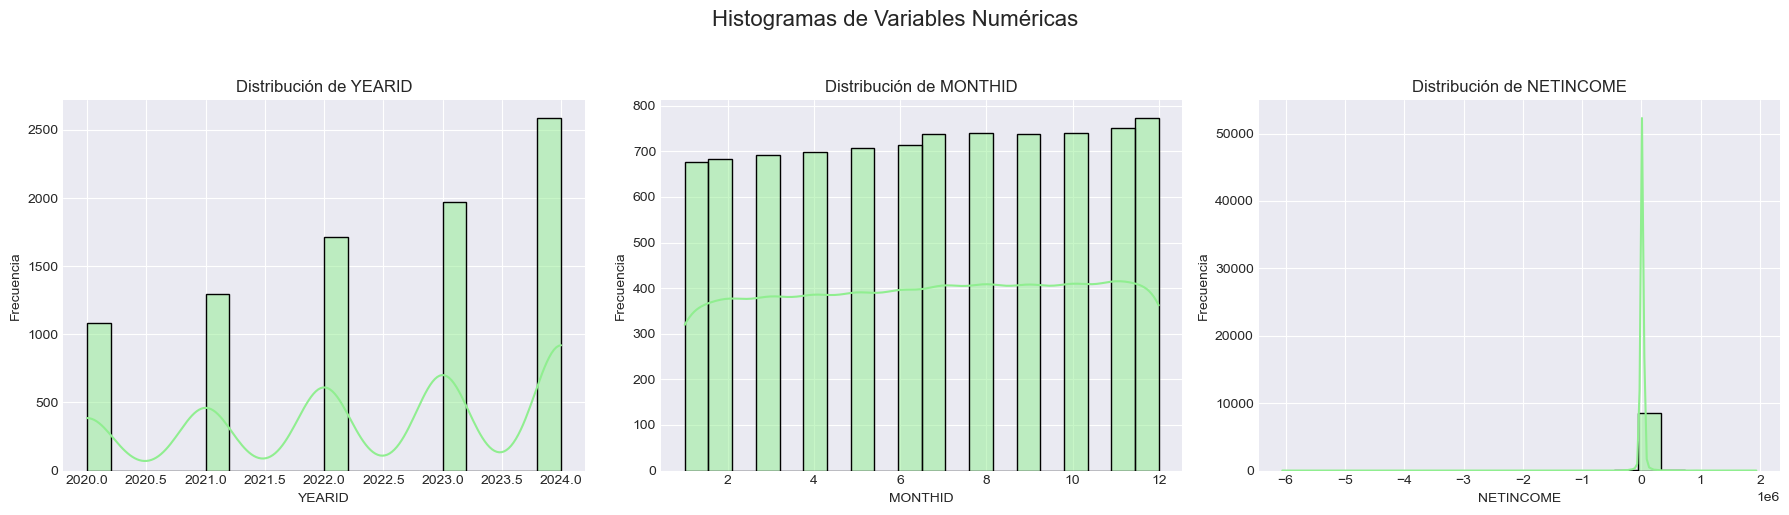

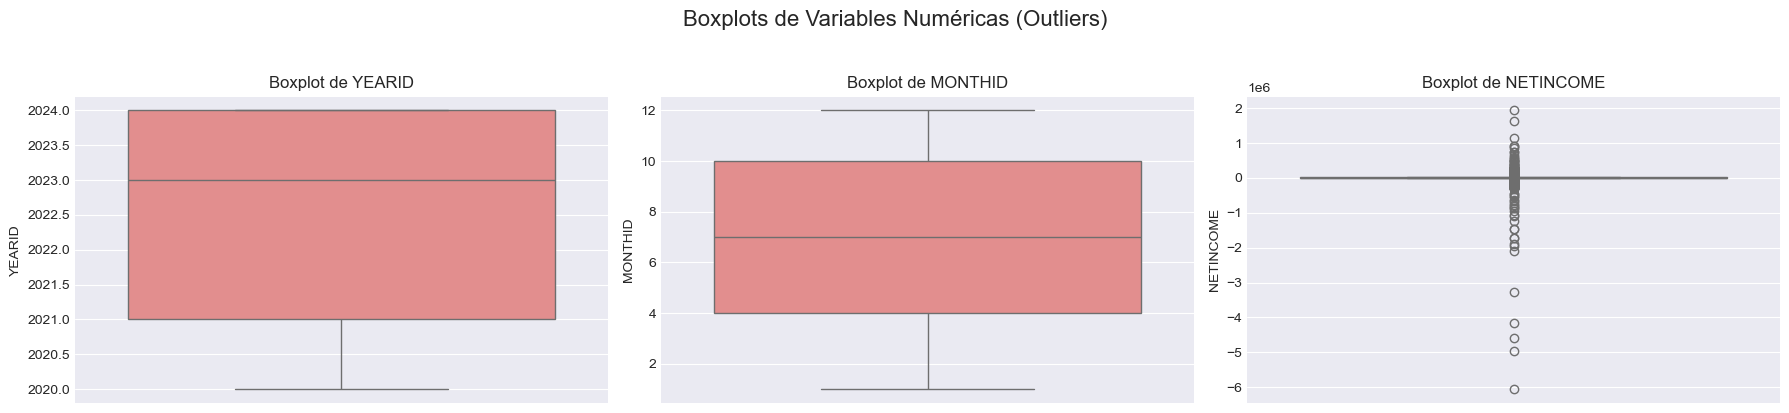

In [9]:
 
# Lista de columnas a remover (variables que no quieres graficar en el bucle principal)
remove_variables = ['LIBDIARIOID', 'ENTERPRISEID', 'PROPERTYID', 'LIBDIATYPEID', 'SOURCEID','ODATAID','COACODDETAIL', 'PORTFOLIOID','ADMIN_ENTITYID', 'TENANTID','DEBIT','CREDIT'] 

# La forma más robusta de crear la lista de columnas numéricas para graficar, 
# EXCLUYENDO las de 'remove_variables'. Se utiliza una comprensión de listas.
# Es mejor crear una nueva lista en lugar de modificar la original directamente, 
# a menos que sea estrictamente necesario.

cols_to_plot = [col for col in numerical_cols if col not in remove_variables]

print("\n--- Distribuciones y Outliers de Variables Numéricas Seleccionadas ---")
print(f"Variables a graficar ({len(cols_to_plot)}): {cols_to_plot}")
print(f"Variables excluidas: {remove_variables}")

# Columnas Numéricas a graficar (excluyendo IDs/Variables a remover)
if cols_to_plot:
    num_plots = len(cols_to_plot)
    cols_per_row = 3
    rows = (num_plots + cols_per_row - 1) // cols_per_row  # Calcular filas necesarias

    # ----------------------------------
    ## Histogramas (Distribuciones)
    # ----------------------------------
    plt.figure(figsize=(cols_per_row * 6, rows * 5))  # Ajustar tamaño de figura
    plt.suptitle('Histogramas de Variables Numéricas', fontsize=16, y=1.02)

    for i, col in enumerate(cols_to_plot):
        if pd.api.types.is_numeric_dtype(df[col]):  # Doble chequeo
            plt.subplot(rows, cols_per_row, i + 1)
            # Asegura que haya datos para graficar antes de llamar a histplot
            if not df[col].empty:
                sns.histplot(df[col], kde=True, bins=20, color='lightgreen')
                plt.title(f'Distribución de {col}', fontsize=12)
                plt.xlabel(col, fontsize=10)
                plt.ylabel('Frecuencia', fontsize=10)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajustar para el suptitle
    plt.show()

    # ---

    # ----------------------------------
    ## Boxplots (Outliers)
    # ----------------------------------
    plt.figure(figsize=(cols_per_row * 6, rows * 4))
    plt.suptitle('Boxplots de Variables Numéricas (Outliers)', fontsize=16, y=1.02)

    for i, col in enumerate(cols_to_plot):
        if pd.api.types.is_numeric_dtype(df[col]):
            plt.subplot(rows, cols_per_row, i + 1)
            if not df[col].empty:
                sns.boxplot(y=df[col], color='lightcoral')
                plt.title(f'Boxplot de {col}', fontsize=12)
                plt.ylabel(col, fontsize=10)
                plt.xlabel('') # Quitar el label x
    
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajustar para el suptitle
    plt.show()


Columnas categóricas originales: ['PKRECORD', 'ENTEPRISENAME', 'PORTFOLIONAME']
Columnas categóricas excluidas: ['PURCHASE_DATE', 'ENTEPRISENAME', 'PKRECORD', 'STATEID']
Columnas categóricas a graficar: ['PORTFOLIONAME']

--- Análisis de Variables Cualitativas (Distribución) ---


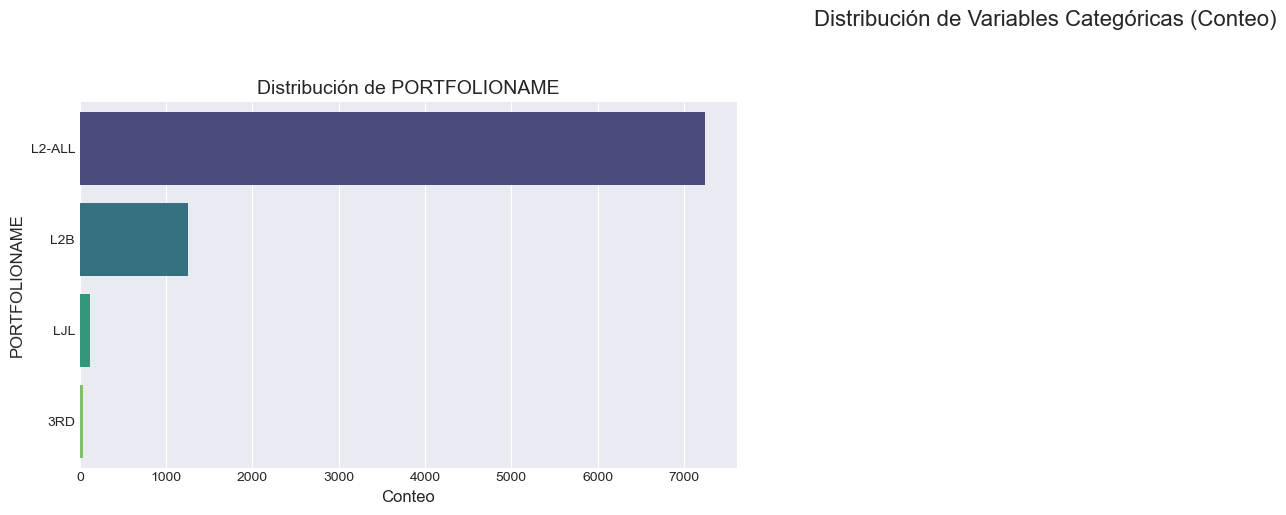


--- Relación entre Variables Categóricas  ---


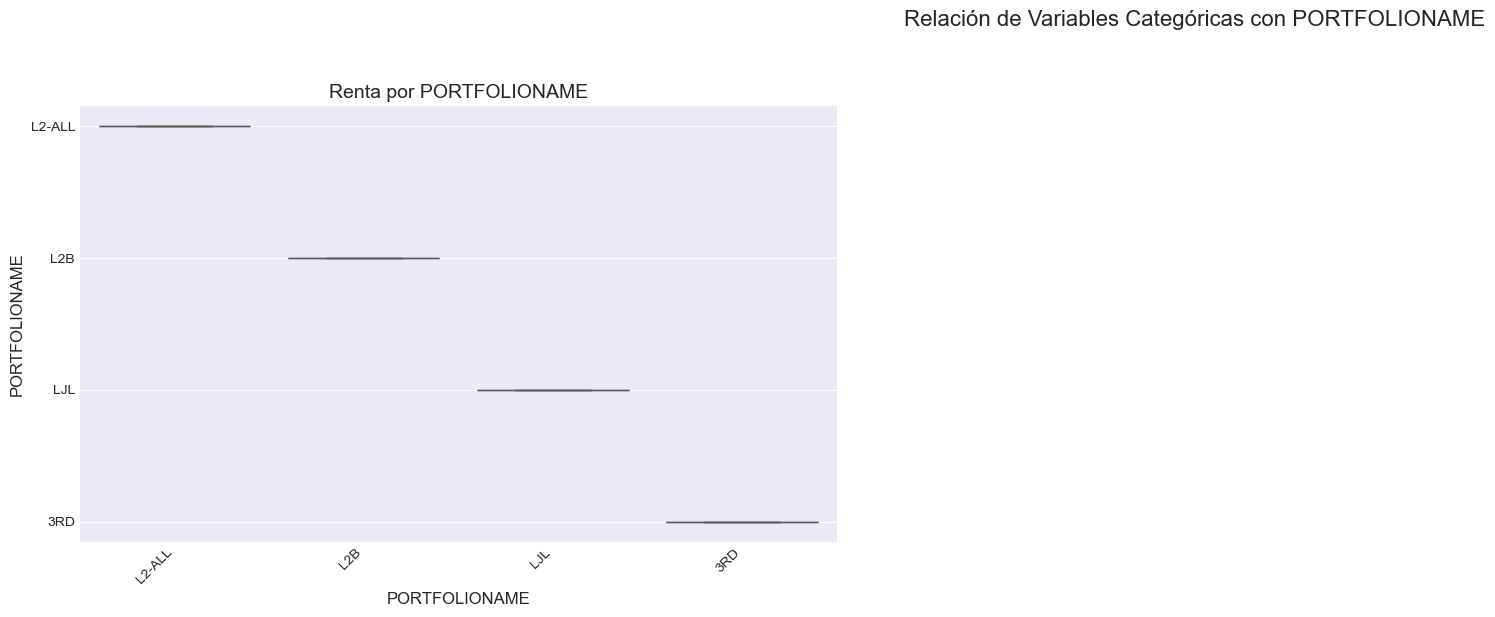

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PASO 1: Definir las columnas a excluir y crear la lista de graficación
# ----------------------------------------------------------------------
# Define las columnas categóricas que deseas excluir de la visualización.
# Por ejemplo, si tienes alguna columna de ID que es categórica pero no relevante para el análisis de distribución.
exclude_categorical_cols = [  'PURCHASE_DATE', 'ENTEPRISENAME','PKRECORD','STATEID' ] 

# Crea la lista final de columnas a graficar utilizando una comprensión de listas.
cols_to_plot = [col for col in categorical_cols if col not in exclude_categorical_cols]

print(f"Columnas categóricas originales: {categorical_cols}")
print(f"Columnas categóricas excluidas: {exclude_categorical_cols}")
print(f"Columnas categóricas a graficar: {cols_to_plot}")

# ----------------------------------------------------------------------
# PASO 2: Análisis y Visualización de Variables Cualitativas (Distribución)
# ----------------------------------------------------------------------

print("\n--- Análisis de Variables Cualitativas (Distribución) ---")
if cols_to_plot:
    num_plots = len(cols_to_plot)
    cols_per_row = 3
    rows = (num_plots + cols_per_row - 1) // cols_per_row
    
    plt.figure(figsize=(cols_per_row * 7, rows * 5))
    plt.suptitle('Distribución de Variables Categóricas (Conteo)', fontsize=16, y=1.02) # Título general

    for i, col in enumerate(cols_to_plot): # Iteramos sobre la lista filtrada
        plt.subplot(rows, cols_per_row, i + 1)
        
        # Uso de 'y' para barras horizontales, facilita la lectura de etiquetas largas
        sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis') 
        
        plt.title(f'Distribución de {col}', fontsize=14)
        plt.xlabel('Conteo', fontsize=12)
        plt.ylabel(col, fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajuste para el suptitle
    plt.show()

# ----------------------------------------------------------------------
# PASO 3: Relación entre categóricas y la variable objetivo (Boxplots)
# ----------------------------------------------------------------------

    print("\n--- Relación entre Variables Categóricas  ---")
    plt.figure(figsize=(cols_per_row * 8, rows * 6))
    plt.suptitle(f'Relación de Variables Categóricas con {target_variable}', fontsize=16, y=1.02)

    for i, col in enumerate(cols_to_plot): # Iteramos sobre la lista filtrada
        plt.subplot(rows, cols_per_row, i + 1)
        
        # Ajuste: Incluir chequeo de cuántas categorías hay
        if df[col].nunique() < 15: # Límite razonable para un boxplot
            sns.boxplot(x=col, y=target_variable, data=df, palette='Set2')
            plt.title(f'Renta por {col}', fontsize=14)
            plt.xlabel(col, fontsize=12)
            plt.ylabel(target_variable, fontsize=12)
            plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor lectura
        else:
            # Imprimir un mensaje o usar otro tipo de gráfico si hay demasiadas categorías
            plt.title(f'{col}: Demasiadas categorías para Boxplot', fontsize=14)
            plt.axis('off') # Ocultar el subplot si no se usa
            print(f"AVISO: La columna '{col}' fue omitida en boxplots por tener {df[col].nunique()} categorías.")


    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("No se encontraron columnas categóricas relevantes para analizar.")


--- Análisis de Correlación ---


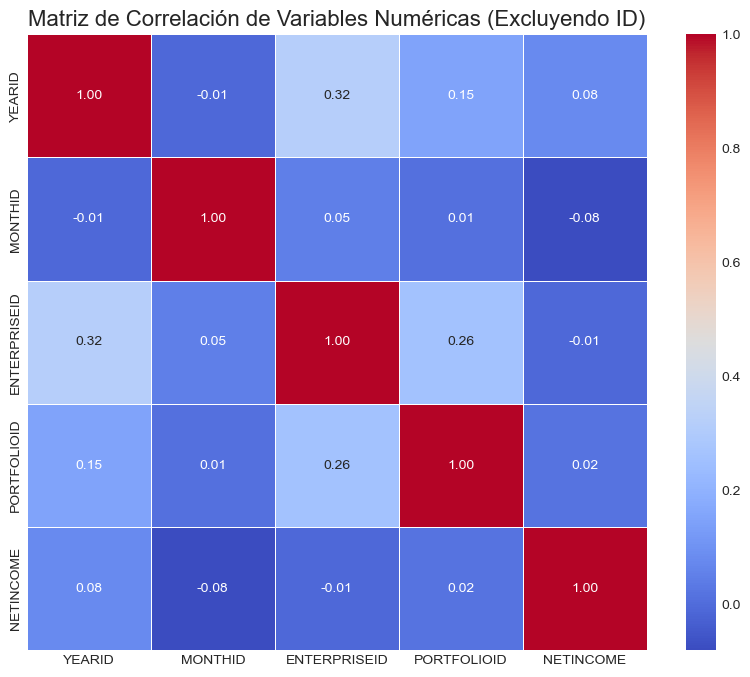


Correlación con la variable objetivo ('NETINCOME'):
NETINCOME       1.00
YEARID          0.08
PORTFOLIOID     0.02
ENTERPRISEID   -0.01
MONTHID        -0.08
Name: NETINCOME, dtype: float64

--- EDA Completo ---
El análisis exploratorio de datos ha finalizado. Revisa los gráficos generados y la salida en consola.


In [11]:
# Convertir 'PURCHASE_DATE' a un formato numérico (e.g., año) si es necesario para correlación
# Si tu columna 'PURCHASE_DATE' ya es numérica o quieres correlacionar el año, haz esto:
 
# Asegurarse de que target_variable existe y definirla
target_variable = 'NETINCOME'

# Identificar columnas numéricas (excluyendo la variable objetivo por ahora para la lista inicial)
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

# --- MEJORA: Lista de columnas a excluir de la matriz de correlación ---
#'TYPETENANT','BUSINESSID',
columns_to_exclude = ['COACODDETAIL','PROPERTYID', 'LIBDIARIOID', 'DEBIT','CREDIT','NET' ] # Puedes añadir más columnas aquí, por ejemplo: 'OTRA_COLUMNA_NO_RELEVANTE'

# --- 7. Análisis de Correlación (para variables numéricas) ---
print("\n--- Análisis de Correlación ---")

# Filtrar las columnas numéricas para excluir las no deseadas
# Creamos una nueva lista `numerical_cols_for_corr` para no modificar la original `numerical_cols`
numerical_cols_for_corr = [col for col in numerical_cols if col not in columns_to_exclude and col != target_variable]


if numerical_cols_for_corr and target_variable in df.columns and target_variable in numerical_cols:
    # Incluimos la variable objetivo para la matriz de correlación
    # Asegúrate de que target_variable también sea numérica si no lo es ya
    correlation_data = df[numerical_cols_for_corr + [target_variable]]
    corr_matrix = correlation_data.corr().round(2)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Matriz de Correlación de Variables Numéricas (Excluyendo ID)', fontsize=16) # Cambiado el título
    plt.show()

    print("\nCorrelación con la variable objetivo ('{}'):".format(target_variable))
    print(corr_matrix[target_variable].sort_values(ascending=False))
else:
    print("No hay suficientes columnas numéricas relevantes para calcular la matriz de correlación o la variable objetivo no es numérica o no está presente.")

print("\n--- EDA Completo ---")
print("El análisis exploratorio de datos ha finalizado. Revisa los gráficos generados y la salida en consola.")
